# Библиотеки

In [1]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline as SparkPipeline, PipelineModel
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier as SparkRandomForestClassifier,
    GBTClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.ensemble import RandomForestClassifier as SklearnRandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, 
    auc,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import pandas as pd

import matplotlib.pyplot as plt

# pyspark

## Загрузка датасета

In [2]:
spark = SparkSession.builder \
    .appName("PySpark_ML") \
    .master("local[*]") \
    .getOrCreate()

print(f"Spark Session успешно создана! Версия Spark: {spark.version}")

Spark Session успешно создана! Версия Spark: 3.5.1


In [3]:
(df := spark.read.csv("work/data/creditcard.csv", header=True, inferSchema=True))

DataFrame[Time: double, V1: double, V2: double, V3: double, V4: double, V5: double, V6: double, V7: double, V8: double, V9: double, V10: double, V11: double, V12: double, V13: double, V14: double, V15: double, V16: double, V17: double, V18: double, V19: double, V20: double, V21: double, V22: double, V23: double, V24: double, V25: double, V26: double, V27: double, V28: double, Amount: double, Class: int]

Данный набор данных содержит информацию о транзакциях, совершенных с помощью кредитных карт европейскими держателями карт в сентябре 2013 года.
В наборе данных представлены транзакции, произошедшие за два дня, из которых 492 случая мошенничества составили 284 807 транзакций. Набор данных сильно несбалансирован: на положительный класс (мошенничество) приходится 0,172% всех транзакций.

Time – количество секунд, прошедших между данной транзакцией и первой транзакцией в наборе данных.

V1-V28 – может быть результатом снижения размерности методом PCA, выполненного для защиты личности пользователей и конфиденциальных признаков (v1–v28).

Amount – сумма транзакции.

Class – 1 для мошеннических транзакций, 0 в противном случае.

## Разведочный анализ

### Качество данных

In [4]:
(df.count(), len(df.columns))

(284807, 31)

Посмотрим на схему датасета

In [5]:
df.printSchema()

root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

Все сходится

Посмотрим на пропуски

In [6]:
n_rows = df.count()

In [7]:
missing_stats = []

for c in df.columns:

    dtype = dict(df.dtypes)[c]

    if dtype in ("double", "float"):
        condition = (
            F.col(c).isNull() |
            F.isnan(F.col(c))
        )
    else:
        condition = F.col(c).isNull()

    missing_count = df.filter(condition).count()

    missing_stats.append(
        (
            c,
            missing_count,
            missing_count / n_rows * 100
        )
    )

In [8]:
missing_df = spark.createDataFrame(
    missing_stats,
    ["column", "missing_count", "missing_percent"]
)

In [9]:
missing_df = (
    missing_df
    .withColumn(
        "missing_percent",
        F.round("missing_percent", 4)
    )
    .orderBy(F.desc("missing_count"))
)

In [10]:
print("\nПропущенные значения:")
missing_df.show(len(df.columns), truncate=False)


Пропущенные значения:
+------+-------------+---------------+
|column|missing_count|missing_percent|
+------+-------------+---------------+
|V12   |0            |0.0            |
|V18   |0            |0.0            |
|V27   |0            |0.0            |
|V19   |0            |0.0            |
|V24   |0            |0.0            |
|V20   |0            |0.0            |
|V28   |0            |0.0            |
|V21   |0            |0.0            |
|V15   |0            |0.0            |
|V22   |0            |0.0            |
|Amount|0            |0.0            |
|V23   |0            |0.0            |
|V25   |0            |0.0            |
|Class |0            |0.0            |
|Time  |0            |0.0            |
|V26   |0            |0.0            |
|V16   |0            |0.0            |
|V6    |0            |0.0            |
|V17   |0            |0.0            |
|V1    |0            |0.0            |
|V3    |0            |0.0            |
|V2    |0            |0.0            |
|V

Явных пропусков не было замечено

Посмотрим на явные дубликаты

In [11]:
n_rows = df.count()

In [12]:
unique_rows = df.dropDuplicates().count()
duplicates = n_rows - unique_rows

In [13]:
print(f"\nВсего строк:      {n_rows:,}")
print(f"Уникальные строки:     {unique_rows:,}")
print(f"Дублированные строки:  {duplicates:,}")
print(f"Доля дубликатов:  {duplicates / n_rows * 100:.4f}%")


Всего строк:      284,807
Уникальные строки:     283,726
Дублированные строки:  1,081
Доля дубликатов:  0.3796%


Было обнаружено 1081 дубликат, посмотрим в каких они классах

In [14]:
duplicates = (
    df.groupBy(df.columns)
      .count()
      .filter(F.col("count") > 1)
)

In [15]:
duplicates.groupBy("Class").agg(
    F.sum(F.col("count") - 1).alias("duplicate_rows")
).show()

+-----+--------------+
|Class|duplicate_rows|
+-----+--------------+
|    1|            19|
|    0|          1062|
+-----+--------------+



В принципе могут существовать идентичные строчки транзакций, так что думаю не будем их пока что удалять

### Анализ целевой переменной

In [16]:
class_distribution = (
    df.groupBy("Class")
      .count()
      .withColumn(
          "percentage",
          F.round(F.col("count") / n_rows * 100, 4)
      )
      .orderBy("Class")
)

In [17]:
class_distribution.show()

+-----+------+----------+
|Class| count|percentage|
+-----+------+----------+
|    0|284315|   99.8273|
|    1|   492|    0.1727|
+-----+------+----------+



In [18]:
normal_count = df.filter(F.col("Class") == 0).count()
fraud_count = df.filter(F.col("Class") == 1).count()

In [19]:
imbalance_ratio = normal_count / fraud_count

In [20]:
print(f"Соотношение Class 0 / Class 1: {imbalance_ratio:.2f}:1")

Соотношение Class 0 / Class 1: 577.88:1


Сильный дисбаланс классов

In [21]:
class_pd = (
    class_distribution
    .orderBy("Class")
    .toPandas()
)

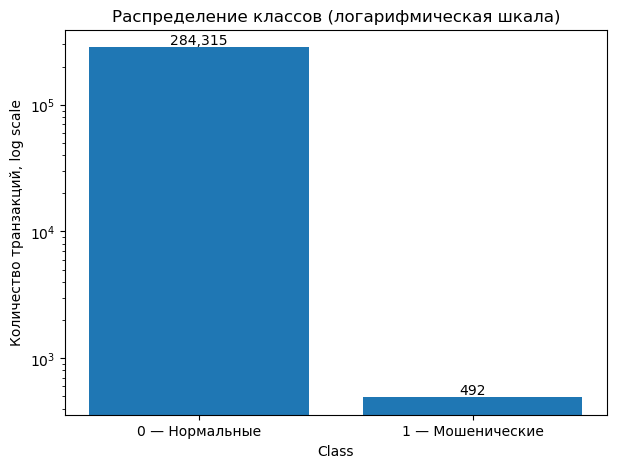

In [22]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_pd["Class"].astype(str),
    class_pd["count"]
)

plt.yscale("log")

plt.title("Распределение классов (логарифмическая шкала)")
plt.xlabel("Class")
plt.ylabel("Количество транзакций, log scale")

plt.xticks(
    [0, 1],
    ["0 — Нормальные", "1 — Мошенические"]
)

for i, row in class_pd.iterrows():
    plt.text(
        i,
        row["count"],
        f'{int(row["count"]):,}',
        ha="center",
        va="bottom"
    )

plt.show()

### Описательная статистика признаков

Начнем с Time и Amount

In [23]:
df.select(
    "Time",
    "Amount"
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
).show(truncate=False)

+-------+------------------+------------------+
|summary|Time              |Amount            |
+-------+------------------+------------------+
|count  |284807            |284807            |
|mean   |94813.85957508067 |88.34961925093698 |
|stddev |47488.145954566266|250.12010924018836|
|min    |0.0               |0.0               |
|25%    |54201.0           |5.58              |
|50%    |84687.0           |22.0              |
|75%    |139317.0          |77.1              |
|max    |172792.0          |25691.16          |
+-------+------------------+------------------+



Заметна правосторонняя асимметрия amount 

In [24]:
p99_amount = df.approxQuantile(
    "Amount",
    [0.99],
    0.001
)[0]

In [25]:
amount_pd = (
    df
    .filter(F.col("Amount") <= p99_amount)
    .select("Amount")
    .toPandas()
)

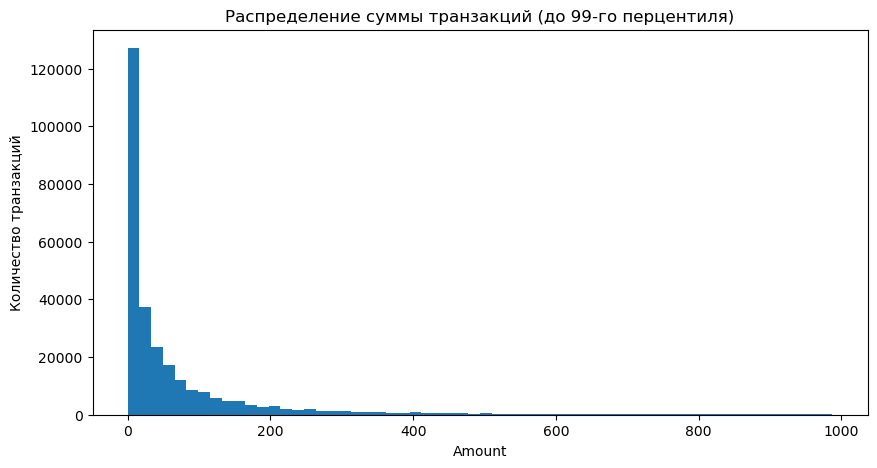

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(
    amount_pd["Amount"],
    bins=60
)

plt.title("Распределение суммы транзакций (до 99-го перцентиля)")
plt.xlabel("Amount")
plt.ylabel("Количество транзакций")

plt.show()

In [27]:
amount_log_pd = (
    df
    .select(
        F.log1p("Amount").alias("log_amount")
    )
    .toPandas()
)

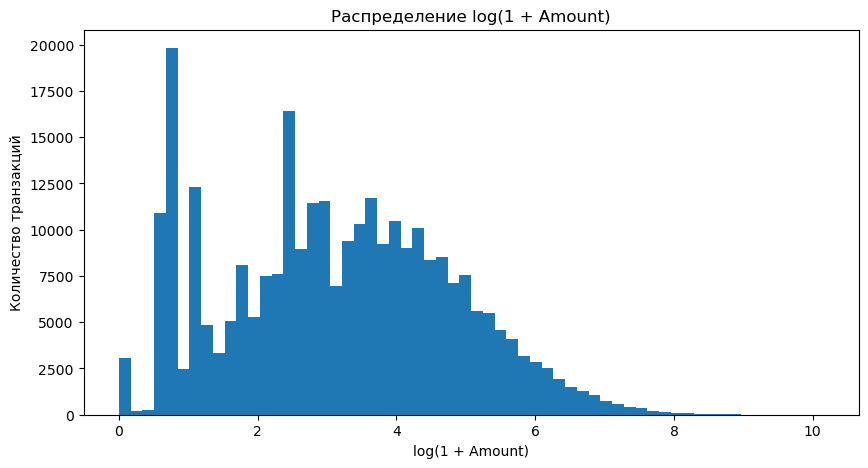

In [28]:
plt.figure(figsize=(10, 5))

plt.hist(
    amount_log_pd["log_amount"],
    bins=60
)

plt.title("Распределение log(1 + Amount)")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Количество транзакций")

plt.show()

После преобразования log(1 + Amount) распределение всё ещё не является симметричным и содержит несколько выраженных локальных пиков

In [29]:
v_columns = [f"V{i}" for i in range(1, 29)]

In [30]:
df.select(v_columns).summary(
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
).show(truncate=False, vertical=True)

-RECORD 0--------------------------
 summary | mean                    
 V1      | 9.516248586879277E-16   
 V2      | -4.151383611725859E-17  
 V3      | -1.3156692677161953E-15 
 V4      | 1.4976914722303291E-15  
 V5      | 8.941441625255696E-16   
 V6      | 1.3971002539462024E-15  
 V7      | -2.6664656275316093E-16 
 V8      | 1.528826849318273E-16   
 V9      | -2.2894481447166985E-15 
 V10     | 2.176532506335261E-15   
 V11     | 1.8074485571052584E-15  
 V12     | -1.2837355476259963E-15 
 V13     | 1.8042551850962386E-15  
 V14     | 9.899453227961663E-16   
 V15     | 4.972080218043971E-15   
 V16     | 1.4585726651198355E-15  
 V17     | -4.0715493115003616E-16 
 V18     | 1.2214647934501085E-15  
 V19     | 1.0039163253356284E-15  
 V20     | 4.770099438473463E-16   
 V21     | 3.718282533002536E-16   
 V22     | -4.630389413078843E-16  
 V23     | 2.9858028284335985E-16  
 V24     | 4.504351011597839E-15   
 V25     | 7.153153300204557E-16   
 V26     | 1.636403568872130

Признаки V1–V28 имеют средние значения, практически равные нулю, что согласуется с их представлением в виде PCA-компонент. При этом масштабы дисперсии различаются: стандартное отклонение уменьшается примерно от 1.96 для V1 до 0.33 для V28. Для ряда компонент наблюдаются экстремальные минимальные и максимальные значения, существенно выходящие за межквартильные диапазоны, что указывает на наличие длинных хвостов и потенциальных выбросов

Различие в v1-v28 в классах 0 и 1

In [31]:
normal_means = (
    df.filter(F.col("Class") == 0)
    .select(*[F.avg(c).alias(c) for c in v_columns])
    .first()
)

fraud_means = (
    df.filter(F.col("Class") == 1)
    .select(*[F.avg(c).alias(c) for c in v_columns])
    .first()
)

In [32]:
differences = []

for c in v_columns:
    differences.append(
        (
            c,
            float(normal_means[c]),
            float(fraud_means[c]),
            abs(float(fraud_means[c]) - float(normal_means[c]))
        )
    )

In [33]:
difference_df = spark.createDataFrame(
    differences,
    [
        "feature",
        "normal_mean",
        "fraud_mean",
        "abs_mean_difference"
    ]
)

difference_df.orderBy(
    F.desc("abs_mean_difference")
).show(28, truncate=False)

+-------+----------------------+--------------------+--------------------+
|feature|normal_mean           |fraud_mean          |abs_mean_difference |
+-------+----------------------+--------------------+--------------------+
|V3     |0.012170917031845774  |-7.033281048596557  |7.045451965628402   |
|V14    |0.012064392184377356  |-6.971722894107602  |6.983787286291979   |
|V17    |0.011535063252129277  |-6.665836399449662  |6.6773714627017915  |
|V12    |0.010831723172555742  |-6.25939303619013   |6.270224759362686   |
|V10    |0.009823703892289603  |-5.676882870194368  |5.686706574086657   |
|V7     |0.009636549929484444  |-5.56873108374274   |5.578367633672225   |
|V1     |0.008257737485563627  |-4.771948441479082  |4.7802061789646455  |
|V4     |-0.00785986782046573  |4.542029104423094   |4.54988897224356    |
|V16    |0.007164072539099559  |-4.139945699092808  |4.147109771631907   |
|V11    |-0.006576104223821637 |3.8001729113746068  |3.8067490155984283  |
|V2     |-0.0062708574158

In [34]:
top_features = ["V3", "V14", "V17", "V12"]

In [35]:
plot_pd = (
    df.select("Class", *top_features)
      .toPandas()
)

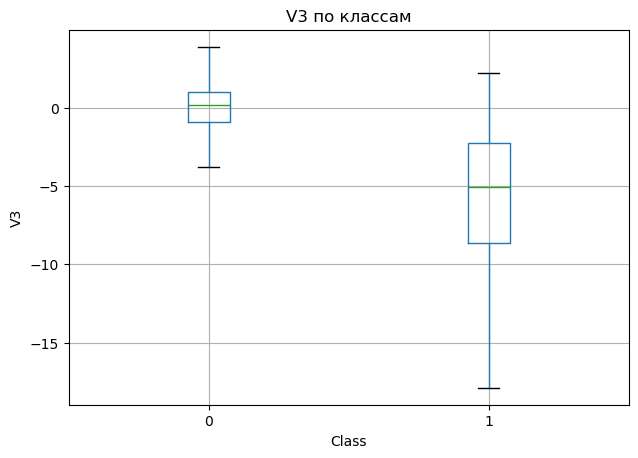

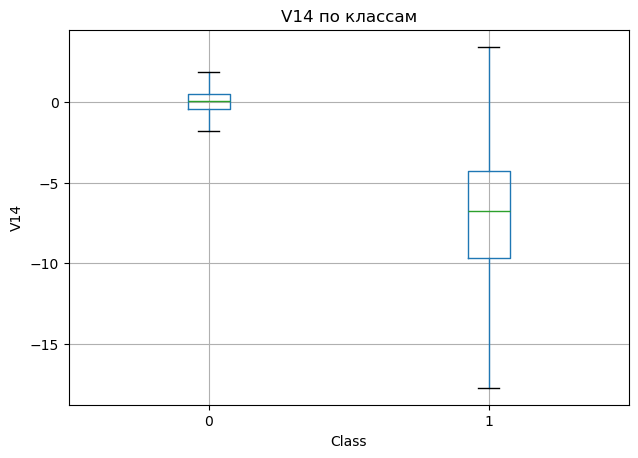

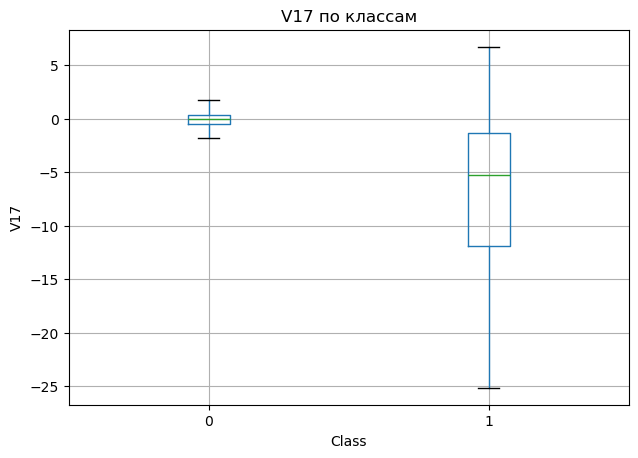

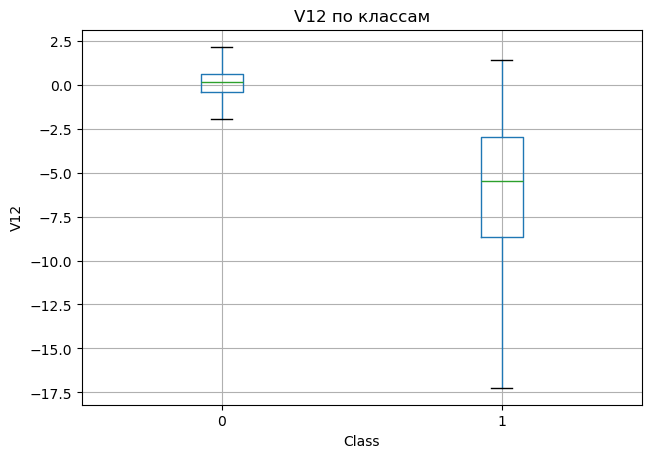

In [36]:
for feature in top_features:

    ax = plot_pd.boxplot(
        column=feature,
        by="Class",
        figsize=(7, 5),
        showfliers=False
    )

    ax.set_title(f"{feature} по классам")
    ax.set_xlabel("Class")
    ax.set_ylabel(feature)

    plt.suptitle("")
    plt.show()

Сравнение средних значений PCA-компонент между классами показывает заметные различия для ряда признаков. Наиболее выраженный сдвиг наблюдается у V3, V14, V17, V12, V10, V7, V1 и V4. Это указывает на то, что данные компоненты могут быть информативны для разделения обычных и мошеннических транзакций

Посмотрим корреляцию каждого V1–V28 с Class

In [37]:
correlations = []

In [38]:
for feature in v_columns:
    corr = df.stat.corr(feature, "Class")

    correlations.append(
        (
            feature,
            corr,
            abs(corr)
        )
    )

In [39]:
corr_df = spark.createDataFrame(
    correlations,
    [
        "feature",
        "correlation_with_class",
        "abs_correlation"
    ]
)

In [40]:
corr_df.orderBy(
    F.desc("abs_correlation")
).show(28, truncate=False)

+-------+----------------------+---------------------+
|feature|correlation_with_class|abs_correlation      |
+-------+----------------------+---------------------+
|V17    |-0.3264810672437196   |0.3264810672437196   |
|V14    |-0.302543695804408    |0.302543695804408    |
|V12    |-0.2605929248772209   |0.2605929248772209   |
|V10    |-0.2168829436410304   |0.2168829436410304   |
|V16    |-0.1965389403040215   |0.1965389403040215   |
|V3     |-0.1929608270674164   |0.1929608270674164   |
|V7     |-0.18725659151430055  |0.18725659151430055  |
|V11    |0.1548756447439496    |0.1548756447439496   |
|V4     |0.133447486239006     |0.133447486239006    |
|V18    |-0.11148525388904278  |0.11148525388904278  |
|V1     |-0.10134729859508633  |0.10134729859508633  |
|V9     |-0.09773268607407982  |0.09773268607407982  |
|V5     |-0.09497429899144971  |0.09497429899144971  |
|V2     |0.09128865034462079   |0.09128865034462079  |
|V6     |-0.0436431606999645   |0.0436431606999645   |
|V21    |0

In [41]:
corr_pd = (
    corr_df
    .orderBy(F.desc("abs_correlation"))
    .toPandas()
)

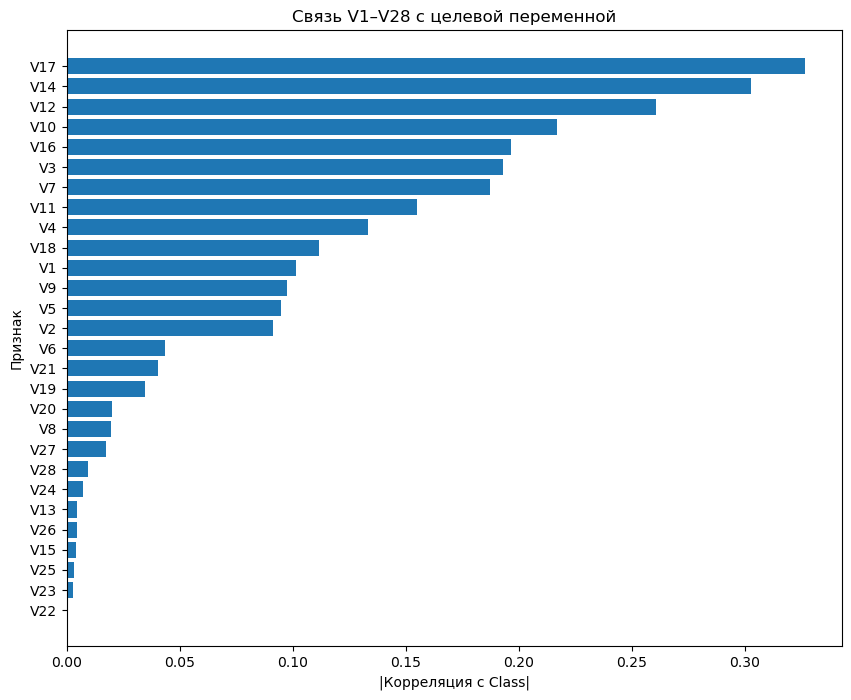

In [42]:
plt.figure(figsize=(10, 8))

plt.barh(
    corr_pd["feature"],
    corr_pd["abs_correlation"]
)

plt.xlabel("|Корреляция с Class|")
plt.ylabel("Признак")
plt.title("Связь V1–V28 с целевой переменной")

plt.gca().invert_yaxis()

plt.show()

### Анализ временного признака Time

In [43]:
df_time = (
    df
    .withColumn(
        "Hour",
        F.floor(F.col("Time") / 3600)
    )
)

In [44]:
hour_stats = (
    df_time
    .groupBy("Hour")
    .agg(
        F.count("*").alias("transactions"),
        F.sum(
            F.when(F.col("Class") == 1, 1).otherwise(0)
        ).alias("frauds")
    )
    .withColumn(
        "fraud_rate_pct",
        F.round(
            F.col("frauds") / F.col("transactions") * 100,
            4
        )
    )
    .orderBy("Hour")
)

hour_stats.show(50, truncate=False)

+----+------------+------+--------------+
|Hour|transactions|frauds|fraud_rate_pct|
+----+------------+------+--------------+
|0   |3963        |2     |0.0505        |
|1   |2217        |2     |0.0902        |
|2   |1576        |21    |1.3325        |
|3   |1821        |13    |0.7139        |
|4   |1082        |6     |0.5545        |
|5   |1681        |11    |0.6544        |
|6   |1831        |3     |0.1638        |
|7   |3368        |23    |0.6829        |
|8   |5179        |5     |0.0965        |
|9   |7878        |15    |0.1904        |
|10  |8288        |2     |0.0241        |
|11  |8517        |43    |0.5049        |
|12  |7732        |9     |0.1164        |
|13  |7585        |9     |0.1187        |
|14  |8029        |13    |0.1619        |
|15  |7836        |14    |0.1787        |
|16  |7786        |14    |0.1798        |
|17  |7882        |12    |0.1522        |
|18  |8607        |15    |0.1743        |
|19  |7994        |7     |0.0876        |
|20  |8980        |8     |0.0891  

In [45]:
hour_pd = hour_stats.toPandas()

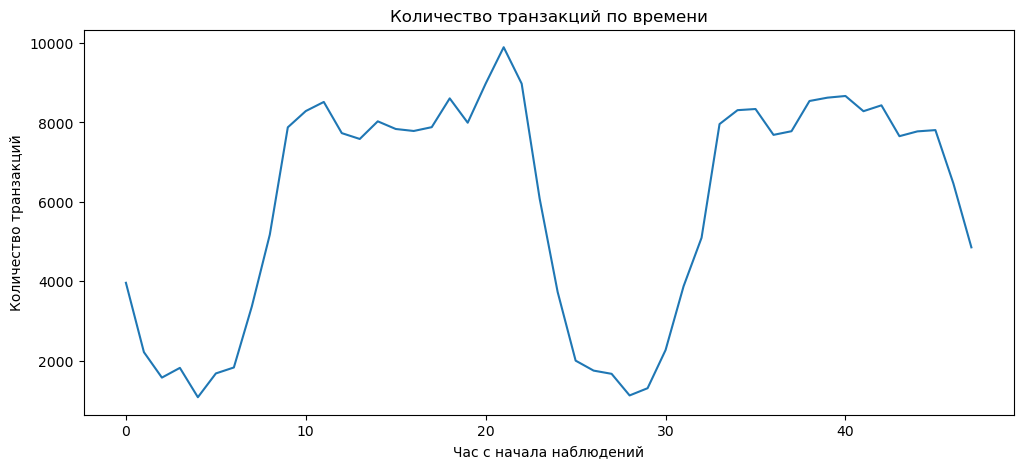

In [46]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_pd["Hour"],
    hour_pd["transactions"]
)

plt.title("Количество транзакций по времени")
plt.xlabel("Час с начала наблюдений")
plt.ylabel("Количество транзакций")

plt.show()

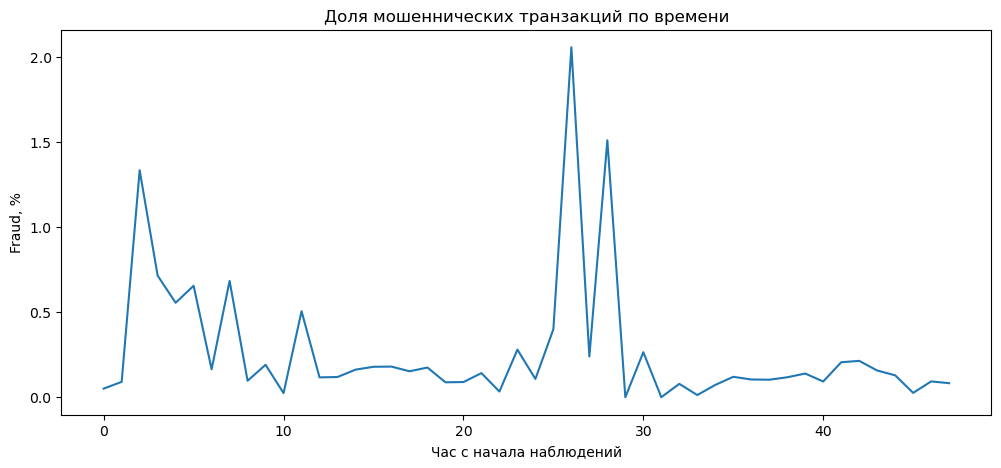

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_pd["Hour"],
    hour_pd["fraud_rate_pct"]
)

plt.title("Доля мошеннических транзакций по времени")
plt.xlabel("Час с начала наблюдений")
plt.ylabel("Fraud, %")

plt.show()

In [48]:
hour_stats.orderBy(
    F.desc("fraud_rate_pct")
).show(10, truncate=False)

+----+------------+------+--------------+
|Hour|transactions|frauds|fraud_rate_pct|
+----+------------+------+--------------+
|26  |1752        |36    |2.0548        |
|28  |1127        |17    |1.5084        |
|2   |1576        |21    |1.3325        |
|3   |1821        |13    |0.7139        |
|7   |3368        |23    |0.6829        |
|5   |1681        |11    |0.6544        |
|4   |1082        |6     |0.5545        |
|11  |8517        |43    |0.5049        |
|25  |2003        |8     |0.3994        |
|23  |6082        |17    |0.2795        |
+----+------------+------+--------------+
only showing top 10 rows



In [49]:
hour_stats.orderBy(
    F.desc("frauds")
).show(10, truncate=False)

+----+------------+------+--------------+
|Hour|transactions|frauds|fraud_rate_pct|
+----+------------+------+--------------+
|11  |8517        |43    |0.5049        |
|26  |1752        |36    |2.0548        |
|7   |3368        |23    |0.6829        |
|2   |1576        |21    |1.3325        |
|42  |8432        |18    |0.2135        |
|23  |6082        |17    |0.2795        |
|28  |1127        |17    |1.5084        |
|41  |8284        |17    |0.2052        |
|9   |7878        |15    |0.1904        |
|18  |8607        |15    |0.1743        |
+----+------------+------+--------------+
only showing top 10 rows



Временной анализ показывает, что периоды с наибольшим абсолютным числом мошеннических транзакций не совпадают с периодами максимальной доли fraud. Например, на 11-м часу зафиксировано максимальное число мошеннических транзакций — 43, однако их доля составляет только 0.50%. В то же время на 26-м часу зафиксировано 36 fraud-транзакций, но при меньшем общем объёме операций это соответствует максимальной доле 2.05%. Это указывает на неоднородность интенсивности мошеннических операций во времени

### Корреляционный анализ признаков

In [50]:
corr_columns = (
    ["Time"]
    + [f"V{i}" for i in range(1, 29)]
    + ["Amount", "Class"]
)

In [51]:
assembler = VectorAssembler(
    inputCols=corr_columns,
    outputCol="features"
)

In [52]:
vector_df = assembler.transform(df).select("features")

In [53]:
corr_matrix = Correlation.corr(
    vector_df,
    "features",
    method="pearson"
).head()[0]

In [54]:
corr_pd = pd.DataFrame(
    corr_matrix.toArray(),
    index=corr_columns,
    columns=corr_columns
)

corr_pd.round(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000,0.117,-0.011,-0.420,-0.105,0.173,-0.063,0.085,-0.037,-0.009,...,0.045,0.144,0.051,-0.016,-0.233,-0.041,-0.005,-0.009,-0.011,-0.012
V1,0.117,1.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,0.000,...,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.228,-0.101
V2,-0.011,-0.000,1.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,...,-0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.531,0.091
V3,-0.420,-0.000,0.000,1.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,...,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.211,-0.193
V4,-0.105,-0.000,-0.000,-0.000,1.000,-0.000,-0.000,-0.000,0.000,0.000,...,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.099,0.133
V5,0.173,0.000,0.000,-0.000,-0.000,1.000,0.000,0.000,0.000,0.000,...,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.386,-0.095
V6,-0.063,0.000,0.000,0.000,-0.000,0.000,1.000,-0.000,-0.000,-0.000,...,-0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.216,-0.044
V7,0.085,0.000,-0.000,-0.000,-0.000,0.000,-0.000,1.000,-0.000,-0.000,...,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.397,-0.187
V8,-0.037,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,1.000,0.000,...,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.103,0.020
V9,-0.009,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,1.000,...,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.044,-0.098


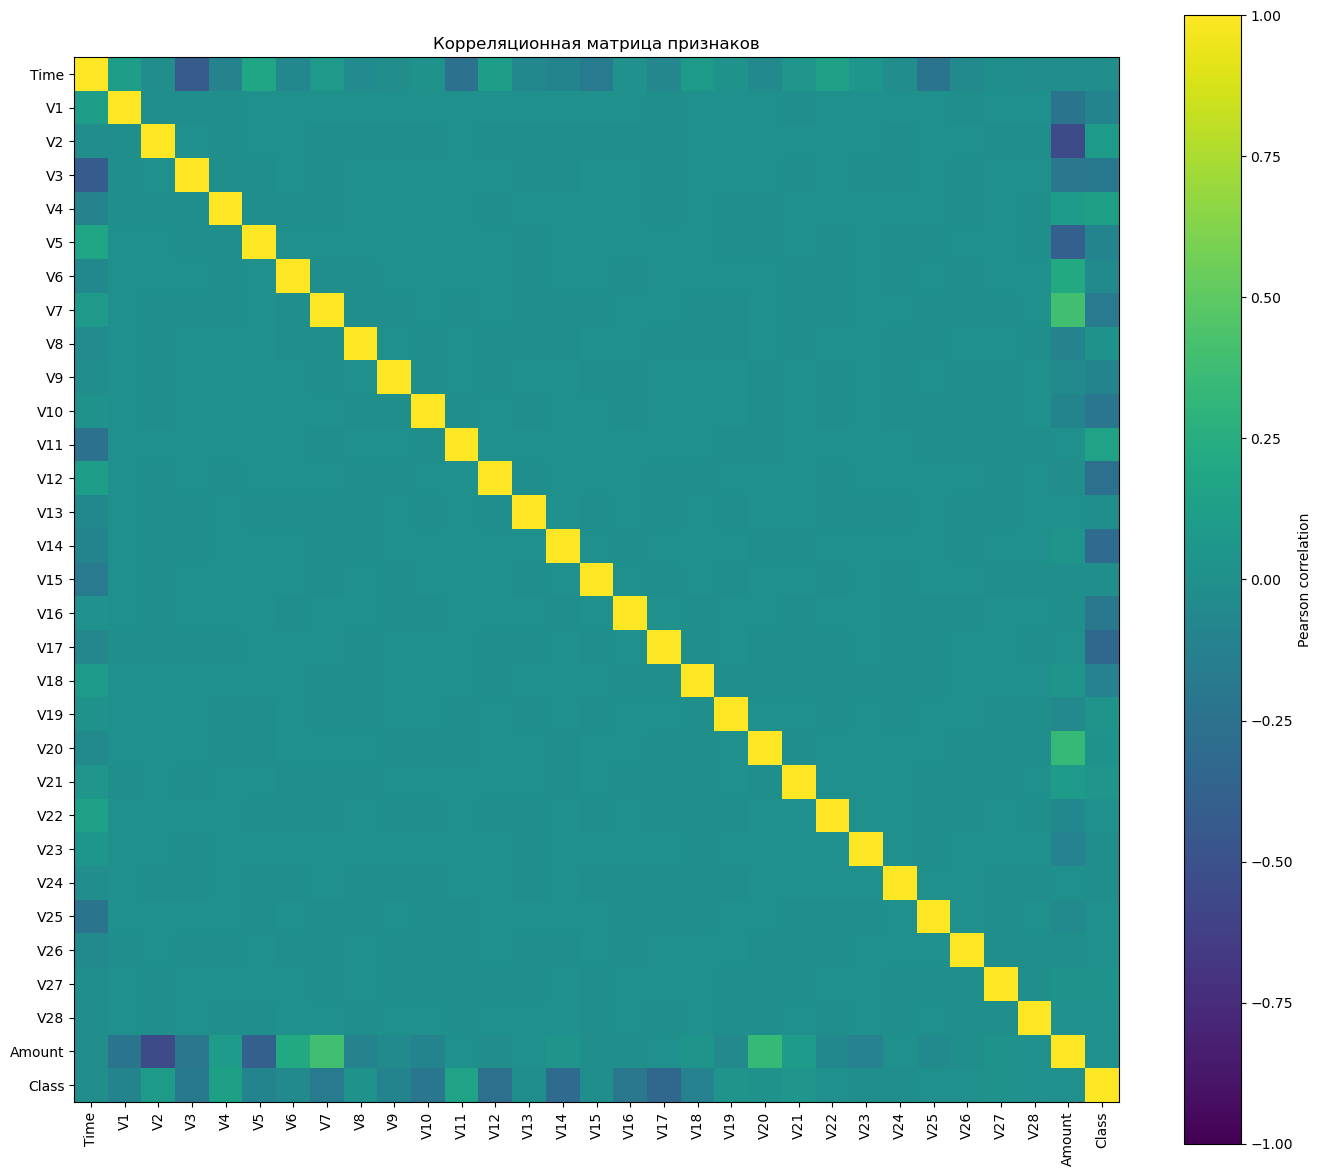

In [55]:
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(
    corr_pd.values,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_columns)))
ax.set_yticks(range(len(corr_columns)))

ax.set_xticklabels(
    corr_columns,
    rotation=90
)

ax.set_yticklabels(corr_columns)

ax.set_title("Корреляционная матрица признаков")

fig.colorbar(
    im,
    ax=ax,
    label="Pearson correlation"
)

plt.tight_layout()
plt.show()

In [56]:
pairs = []

In [57]:
for i in range(len(corr_columns)):
    for j in range(i + 1, len(corr_columns)):

        feature_1 = corr_columns[i]
        feature_2 = corr_columns[j]

        if "Class" in (feature_1, feature_2):
            continue

        corr = corr_pd.loc[feature_1, feature_2]

        pairs.append(
            (
                feature_1,
                feature_2,
                corr,
                abs(corr)
            )
        )

In [58]:
pairs_df = pd.DataFrame(
    pairs,
    columns=[
        "feature_1",
        "feature_2",
        "correlation",
        "abs_correlation"
    ]
)

In [59]:
pairs_df.sort_values(
    "abs_correlation",
    ascending=False
).head(15)

,feature_1,feature_2,correlation,abs_correlation
83,V2,Amount,-0.531409,0.531409
2,Time,V3,-0.419618,0.419618
203,V7,Amount,0.397311,0.397311
158,V5,Amount,-0.386356,0.386356
398,V20,Amount,0.339403,0.339403
10,Time,V11,-0.247689,0.247689
24,Time,V25,-0.233083,0.233083
56,V1,Amount,-0.227709,0.227709
181,V6,Amount,0.215981,0.215981
109,V3,Amount,-0.210880,0.210880


Корреляционный анализ показал отсутствие выраженной линейной зависимости между PCA-компонентами V1–V28. Наиболее заметные связи наблюдаются между Amount и отдельными компонентами: V2 (r = -0.531), V7 (r = 0.397), V5 (r = -0.386) и V20 (r = 0.339). Также выявлена умеренная отрицательная связь между Time и V3 (r = -0.420). Таким образом, существенной мультиколлинеарности среди PCA-компонент не наблюдается, однако Amount и Time линейно связаны с рядом преобразованных признаков

### Анализ выбросов и экстремальных значений

Начнем с Amount

In [60]:
q1, q3 = df.approxQuantile(
    "Amount",
    [0.25, 0.75],
    0.001
)

In [61]:
iqr = q3 - q1

In [62]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [63]:
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

Q1: 5.55
Q3: 76.94
IQR: 71.39
Lower bound: -101.54
Upper bound: 184.03


In [64]:
amount_outliers = df.filter(
    (F.col("Amount") < lower_bound) |
    (F.col("Amount") > upper_bound)
)

In [65]:
outlier_count = amount_outliers.count()

In [66]:
print(f"Количество выбросов по IQR: {outlier_count:,}")
print(
    f"Доля выбросов: "
    f"{outlier_count / n_rows * 100:.2f}%"
)

Количество выбросов по IQR: 31,954
Доля выбросов: 11.22%


In [67]:
(
    amount_outliers
    .groupBy("Class")
    .count()
    .withColumn(
        "percentage_inside_outliers",
        F.round(
            F.col("count") / outlier_count * 100,
            2
        )
    )
    .orderBy("Class")
    .show()
)

+-----+-----+--------------------------+
|Class|count|percentage_inside_outliers|
+-----+-----+--------------------------+
|    0|31863|                     99.72|
|    1|   91|                      0.28|
+-----+-----+--------------------------+



Признак Amount содержит значительное число экстремальных значений относительно межквартильного диапазона. Однако такие значения не следует автоматически интерпретировать как ошибки, поскольку крупные суммы могут отражать реальные транзакции и потенциально содержать полезный сигнал для обнаружения мошенничества

Продолжим с V1-V28

In [68]:
outlier_stats = []

for feature in v_columns:
    
    q1, q3 = df.approxQuantile(
        feature,
        [0.25, 0.75],
        0.001
    )

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        df.filter(
            (F.col(feature) < lower_bound) |
            (F.col(feature) > upper_bound)
        )
        .count()
    )

    outlier_percent = outlier_count / n_rows * 100

    outlier_stats.append(
        (
            feature,
            q1,
            q3,
            iqr,
            lower_bound,
            upper_bound,
            outlier_count,
            outlier_percent
        )
    )

In [69]:
outlier_df = spark.createDataFrame(
    outlier_stats,
    [
        "feature",
        "q1",
        "q3",
        "iqr",
        "lower_bound",
        "upper_bound",
        "outlier_count",
        "outlier_percent"
    ]
)

In [70]:
outlier_df.orderBy(
    F.desc("outlier_percent")
).show(28, truncate=False)

+-------+-------------------+------------------+------------------+--------------------+-------------------+-------------+-------------------+
|feature|q1                 |q3                |iqr               |lower_bound         |upper_bound        |outlier_count|outlier_percent    |
+-------+-------------------+------------------+------------------+--------------------+-------------------+-------------+-------------------+
|V27    |-0.0709551318609425|0.0905098352948669|0.1614649671558094|-0.3131525825946566 |0.332707286028581  |39351        |13.816725010270112 |
|V28    |-0.0530301664038237|0.077881438174396 |0.1309116045782197|-0.24939757327115325|0.27424884504172553|30478        |10.701281920739307 |
|V20    |-0.212083170247905 |0.132235892195906 |0.344319062443811 |-0.7285617639136215 |0.6487144858616225 |27831        |9.771880606867105  |
|V8     |-0.208986131010649 |0.325737432463214 |0.534723563473863 |-1.0110714762214434 |1.1278227776740084 |24231        |8.507866730803668  |

In [71]:
top_outliers = (
    outlier_df
    .orderBy(F.desc("outlier_percent"))
    .limit(10)
)

In [72]:
top_outliers.select(
    "feature",
    "outlier_count",
    F.round("outlier_percent", 2).alias("outlier_percent")
).show()

+-------+-------------+---------------+
|feature|outlier_count|outlier_percent|
+-------+-------------+---------------+
|    V27|        39351|          13.82|
|    V28|        30478|           10.7|
|    V20|        27831|           9.77|
|     V8|        24231|           8.51|
|     V6|        23015|           8.08|
|    V23|        18598|           6.53|
|    V12|        15347|           5.39|
|    V21|        14505|           5.09|
|    V14|        14176|           4.98|
|     V2|        13547|           4.76|
+-------+-------------+---------------+



Для ряда PCA-компонент наблюдаются значения, существенно выходящие за межквартильный диапазон. Однако такие наблюдения не будут удаляться, поскольку экстремальные значения могут быть естественной частью распределения признаков и потенциально содержать информацию, полезную для обнаружения мошеннических транзакций.

## Разделение на train/test

In [73]:
train_df, test_df = df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [74]:
train_df.cache()
test_df.cache()

DataFrame[Time: double, V1: double, V2: double, V3: double, V4: double, V5: double, V6: double, V7: double, V8: double, V9: double, V10: double, V11: double, V12: double, V13: double, V14: double, V15: double, V16: double, V17: double, V18: double, V19: double, V20: double, V21: double, V22: double, V23: double, V24: double, V25: double, V26: double, V27: double, V28: double, Amount: double, Class: int]

In [75]:
print(f"Train: {train_df.count():,}")
print(f"Test:  {test_df.count():,}")

Train: 228,045
Test:  56,762


In [76]:
def class_distribution(data):
    total = data.count()

    return (
        data
        .groupBy("Class")
        .count()
        .withColumn(
            "percentage",
            F.round(F.col("count") / total * 100, 4)
        )
        .orderBy("Class")
    )

In [77]:
print("TRAIN:")
class_distribution(train_df).show()


TRAIN:
+-----+------+----------+
|Class| count|percentage|
+-----+------+----------+
|    0|227645|   99.8246|
|    1|   400|    0.1754|
+-----+------+----------+



In [78]:
print("TEST:")
class_distribution(test_df).show()

TEST:
+-----+-----+----------+
|Class|count|percentage|
+-----+-----+----------+
|    0|56670|   99.8379|
|    1|   92|    0.1621|
+-----+-----+----------+



## Pipeline

In [79]:
feature_columns = (
    ["Time"]
    + [f"V{i}" for i in range(1, 29)]
    + ["Amount"]
)

In [80]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features_raw"
)

In [81]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

In [82]:
pipeline = SparkPipeline(
    stages=[
        assembler,
        scaler
    ]
)

In [83]:
pipeline_model = pipeline.fit(train_df)

In [84]:
train_prepared = pipeline_model.transform(train_df)
test_prepared = pipeline_model.transform(test_df)

### Подбор гиперпараметров

In [85]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="Class",
    maxIter=100
)

In [86]:
pipeline = SparkPipeline(
    stages=[
        assembler,
        scaler,
        lr
    ]
)

In [87]:
param_grid = (
    ParamGridBuilder()
    .addGrid(
        lr.regParam,
        [0.0, 0.01, 0.1]
    )
    .addGrid(
        lr.elasticNetParam,
        [0.0, 0.5, 1.0]
    )
    .build()
)

print("Количество комбинаций:", len(param_grid))

Количество комбинаций: 9


In [88]:
evaluator = BinaryClassificationEvaluator(
    labelCol="Class",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

In [89]:
tvs = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    trainRatio=0.8,
    seed=42,
    parallelism=4
)

In [90]:
tvs_model = tvs.fit(train_df)

In [91]:
best_model = tvs_model.bestModel

In [92]:
best_lr = best_model.stages[-1]

print("Best regParam:",
      best_lr.getRegParam())

print("Best elasticNetParam:",
      best_lr.getElasticNetParam())

print("Best maxIter:",
      best_lr.getMaxIter())

Best regParam: 0.0
Best elasticNetParam: 0.5
Best maxIter: 100


In [93]:
predictions = best_model.transform(test_df)

In [94]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features_raw"
)

### Logistic Regression

In [95]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

In [96]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="Class",
    regParam=best_lr.getRegParam(),
    elasticNetParam=best_lr.getElasticNetParam(),
    maxIter=best_lr.getMaxIter()
)

In [97]:
lr_pipeline = SparkPipeline(
    stages=[
        assembler,
        scaler,
        lr
    ]
)

#### Random Forest

In [98]:
rf = SparkRandomForestClassifier(
    featuresCol="features_raw",
    labelCol="Class",
    numTrees=100,
    maxDepth=10,
    seed=42
)

In [99]:
rf_pipeline = SparkPipeline(
    stages=[
        assembler,
        rf
    ]
)

#### Gradient-Boosted Trees

In [100]:
gbt = GBTClassifier(
    featuresCol="features_raw",
    labelCol="Class",
    maxIter=100,
    maxDepth=5,
    seed=42
)

In [101]:
gbt_pipeline = SparkPipeline(
    stages=[
        assembler,
        gbt
    ]
)

#### Обучение

In [102]:
lr_model = lr_pipeline.fit(train_df)
rf_model = rf_pipeline.fit(train_df)
gbt_model = gbt_pipeline.fit(train_df)

In [103]:
lr_predictions = lr_model.transform(test_df)
rf_predictions = rf_model.transform(test_df)
gbt_predictions = gbt_model.transform(test_df)

Из-за сильного дисбаланса основную метрику лучше взять areaUnderPR

In [104]:
pr_evaluator = BinaryClassificationEvaluator(
    labelCol="Class",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

In [105]:
roc_evaluator = BinaryClassificationEvaluator(
    labelCol="Class",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [106]:
results = []

for model_name, predictions in [
    ("Logistic Regression", lr_predictions),
    ("Random Forest", rf_predictions),
    ("GBT", gbt_predictions)
]:
    
    pr_auc = pr_evaluator.evaluate(predictions)
    roc_auc = roc_evaluator.evaluate(predictions)

    results.append(
        (
            model_name,
            pr_auc,
            roc_auc
        )
    )

In [107]:
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="precisionByLabel",
    metricLabel=1.0
)

In [108]:
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="recallByLabel",
    metricLabel=1.0
)

In [109]:
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="Class",
    predictionCol="prediction",
    metricName="fMeasureByLabel",
    metricLabel=1.0
)

In [110]:
results = []

for model_name, predictions in [
    ("Logistic Regression", lr_predictions),
    ("Random Forest", rf_predictions),
    ("GBT", gbt_predictions)
]:

    results.append(
        (
            model_name,
            pr_evaluator.evaluate(predictions),
            roc_evaluator.evaluate(predictions),
            precision_evaluator.evaluate(predictions),
            recall_evaluator.evaluate(predictions),
            f1_evaluator.evaluate(predictions)
        )
    )

In [111]:
results_df = spark.createDataFrame(
    results,
    [
        "model",
        "PR_AUC",
        "ROC_AUC",
        "Precision_class_1",
        "Recall_class_1",
        "F1_class_1"
    ]
)

results_df.show(truncate=False)

+-------------------+------------------+------------------+------------------+------------------+------------------+
|model              |PR_AUC            |ROC_AUC           |Precision_class_1 |Recall_class_1    |F1_class_1        |
+-------------------+------------------+------------------+------------------+------------------+------------------+
|Logistic Regression|0.7054543975550011|0.9627581689568137|0.8823529411764706|0.6521739130434783|0.75              |
|Random Forest      |0.7969886183879027|0.9762873923017317|0.9230769230769231|0.782608695652174 |0.8470588235294118|
|GBT                |0.7904348591079872|0.9814094375522668|0.8974358974358975|0.7608695652173914|0.8235294117647058|
+-------------------+------------------+------------------+------------------+------------------+------------------+



Среди рассмотренных моделей наилучший результат показал Random Forest. Модель достигла PR-AUC = 0.797, Precision = 0.923, Recall = 0.783 и F1 = 0.847 для мошеннического класса. Это означает, что модель корректно обнаружила примерно 78.3% мошеннических транзакций, при этом около 92.3% операций, классифицированных как мошеннические, действительно относились к классу fraud. Logistic Regression показала наиболее слабые результаты (F1 = 0.750), а GBT заняла промежуточное положение (F1 = 0.824). Несмотря на максимальный ROC-AUC у GBT (0.981), Random Forest превосходит её по PR-AUC, precision, recall и F1 для редкого целевого класса, поэтому среди рассмотренных моделей Random Forest является предпочтительной.

## Сохраним на диск и проверим модель

Сохраним модель

In [112]:
model_path = "models/creditcard_rf_pipeline"

In [113]:
rf_model.write().overwrite().save(model_path)

Загрузим модель

In [114]:
loaded_model = PipelineModel.load(model_path)

Применим загруженную модель

In [115]:
loaded_predictions = loaded_model.transform(test_df)

In [116]:
loaded_predictions.select(
    "Class",
    "probability",
    "prediction"
).show(10, truncate=False)

+-----+------------------------------------------+----------+
|Class|probability                               |prediction|
+-----+------------------------------------------+----------+
|0    |[0.9898797098252383,0.010120290174761718] |0.0       |
|0    |[0.9999136166503524,8.638334964751978E-5] |0.0       |
|0    |[0.9899534835377439,0.010046516462256107] |0.0       |
|0    |[0.9998946690540206,1.0533094597948941E-4]|0.0       |
|0    |[0.9999325150966137,6.74849033862224E-5]  |0.0       |
|0    |[0.9997021978821737,2.97802117826202E-4]  |0.0       |
|0    |[0.9999355901553892,6.440984461074773E-5] |0.0       |
|0    |[0.999928234669104,7.176533089603216E-5]  |0.0       |
|0    |[0.9999188444865794,8.115551342051299E-5] |0.0       |
|0    |[0.9999570567159154,4.2943284084566627E-5]|0.0       |
+-----+------------------------------------------+----------+
only showing top 10 rows



In [117]:
loaded_pr_auc = pr_evaluator.evaluate(loaded_predictions)
loaded_roc_auc = roc_evaluator.evaluate(loaded_predictions)

In [118]:
loaded_precision = precision_evaluator.evaluate(loaded_predictions)
loaded_recall = recall_evaluator.evaluate(loaded_predictions)
loaded_f1 = f1_evaluator.evaluate(loaded_predictions)

In [119]:
print(f"PR-AUC:    {loaded_pr_auc:.6f}")
print(f"ROC-AUC:   {loaded_roc_auc:.6f}")
print(f"Precision: {loaded_precision:.6f}")
print(f"Recall:    {loaded_recall:.6f}")
print(f"F1:        {loaded_f1:.6f}")

PR-AUC:    0.796988
ROC-AUC:   0.976284
Precision: 0.923077
Recall:    0.782609
F1:        0.847059


Результаты те же, все работает верно

# sklearn

Загрузка датасета

In [120]:
df_pd = pd.read_csv("work/data/creditcard.csv")

In [121]:
train_legit = train_df.filter(F.col("Class") == 0)
train_fraud = train_df.filter(F.col("Class") == 1)

In [122]:
test_legit = test_df.filter(F.col("Class") == 0)
test_fraud = test_df.filter(F.col("Class") == 1)

In [123]:
train_legit_sample = train_legit.sample(
    withReplacement=False,
    fraction=0.10,
    seed=42
)

In [124]:
test_legit_sample = test_legit.sample(
    withReplacement=False,
    fraction=0.10,
    seed=42
)

In [125]:
train_sample = train_legit_sample.unionByName(train_fraud)

In [126]:
test_sample = test_legit_sample.unionByName(test_fraud)

In [127]:
train_sample = train_sample.orderBy(F.rand(seed=42))
test_sample = test_sample.orderBy(F.rand(seed=42))

In [128]:
train_pd = train_sample.toPandas()
test_pd = test_sample.toPandas()

Делим на train/test

In [129]:
X_train_sk = train_pd[feature_columns]
y_train_sk = train_pd["Class"]

In [130]:
X_test_sk = test_pd[feature_columns]
y_test_sk = test_pd["Class"]

In [131]:
print("Train:", len(y_train_sk))
print("Test:", len(y_test_sk))

Train: 23187
Test: 5766


Для Random Forest масштабирование не требуется, поэтому sklearn Pipeline здесь очень простой

In [132]:
sklearn_pipeline = SklearnPipeline([
    (
        "model",
        SklearnRandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
    )
])

Обучаем

In [133]:
sklearn_pipeline.fit(
    X_train_sk,
    y_train_sk
)

Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=10, n_jobs=-1,
                                        random_state=42))])

In [134]:
sk_pred = sklearn_pipeline.predict(X_test_sk)

In [135]:
sk_proba = sklearn_pipeline.predict_proba(
    X_test_sk
)[:, 1]

In [136]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test_sk,
    sk_proba
)

In [137]:
sk_pr_auc = auc(recall_curve, precision_curve)

In [138]:
sk_roc_auc = roc_auc_score(
    y_test_sk,
    sk_proba
)

In [139]:
sk_precision = precision_score(
    y_test_sk,
    sk_pred
)

In [140]:
sk_recall = recall_score(
    y_test_sk,
    sk_pred
)

In [141]:
sk_f1 = f1_score(
    y_test_sk,
    sk_pred
)

# Сравниваем pyspark и sklearn

In [142]:
print(f"PR-AUC:    {sk_pr_auc:.4f}")
print(f"ROC-AUC:   {sk_roc_auc:.4f}")
print(f"Precision: {sk_precision:.4f}")
print(f"Recall:    {sk_recall:.4f}")
print(f"F1:        {sk_f1:.4f}")

PR-AUC:    0.9033
ROC-AUC:   0.9819
Precision: 0.9620
Recall:    0.8261
F1:        0.8889


In [143]:
print(
    confusion_matrix(
        y_test_sk,
        sk_pred
    )
)

[[5671    3]
 [  16   76]]


In [144]:
print(f"PR-AUC:    {loaded_pr_auc:.6f}")
print(f"ROC-AUC:   {loaded_roc_auc:.6f}")
print(f"Precision: {loaded_precision:.6f}")
print(f"Recall:    {loaded_recall:.6f}")
print(f"F1:        {loaded_f1:.6f}")

PR-AUC:    0.796988
ROC-AUC:   0.976284
Precision: 0.923077
Recall:    0.782609
F1:        0.847059


In [145]:
cm = (
    rf_predictions
    .groupBy("Class", "prediction")
    .count()
)

In [146]:
tn = cm.filter(
    (F.col("Class") == 0) &
    (F.col("prediction") == 0)
).select("count").first()[0]

In [147]:
fp = cm.filter(
    (F.col("Class") == 0) &
    (F.col("prediction") == 1)
).select("count").first()[0]

In [148]:
fn = cm.filter(
    (F.col("Class") == 1) &
    (F.col("prediction") == 0)
).select("count").first()[0]

In [149]:
tp = cm.filter(
    (F.col("Class") == 1) &
    (F.col("prediction") == 1)
).select("count").first()[0]

In [150]:
print("Confusion Matrix")
print(f"""
              Predicted
              0       1
Actual 0   {tn:5d}   {fp:5d}
Actual 1   {fn:5d}   {tp:5d}
""")

Confusion Matrix

              Predicted
              0       1
Actual 0   56664       6
Actual 1      20      72



В рамках проведённого эксперимента модель, построенная средствами sklearn, показала более высокие значения всех рассматриваемых метрик: PR-AUC составил 0.9033 против 0.7970 у PySpark, ROC-AUC — 0.9819 против 0.9763, Precision — 0.9620 против 0.9231, Recall — 0.8261 против 0.7826, а F1-score — 0.8889 против 0.8471.

При этом прямое сравнение качества следует интерпретировать с осторожностью, поскольку sklearn-модель обучалась на специально сформированной подвыборке, где были сохранены все мошеннические операции и уменьшено количество обычных транзакций. Это изменило соотношение классов по сравнению с исходными данными и могло повлиять на итоговые метрики.

С точки зрения процесса разработки sklearn удобнее для локальных экспериментов и работы с небольшими объёмами данных: его API компактнее, обучение и подбор моделей проще выполнять на одной машине. Spark ML, напротив, ориентирован на распределённую обработку больших наборов данных и позволяет выполнять подготовку данных, обучение и применение моделей непосредственно в Spark-кластере без переноса полного датасета в память одной машины.